# Ejemplo de construcción y uso del gramiano de controlabilidad para un sistema LTI

*(Traducción a Python del livescript `gramiano_ctrl.mlx`, usando `numpy`, `scipy` y `control`)*

Para un sistema LTI (un par $A,B$) el gramiano de alcanzabilidad se define como,

$$W_C[t_1,0] = \int_0^{t_1} e^{-At}BB^Te^{-A^Tt}\,dt$$

donde por razones (espero) conocidas estamos tomando directamente $t_0 = 0$.

Podemos definir una función en Python que calcule el integrando $e^{-At}BB^Te^{-A^Tt}$ para cualquier valor de $t$ (ver la función `dgramc` al final del notebook) e integrarla numéricamente.

In [1]:
import numpy as np
import control as ct
from scipy.linalg import expm
from scipy.integrate import quad_vec, solve_ivp
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)

Vamos a ver cómo hacerlo con un par $(A,B)$ de ejemplo,

$$\dot{x} = \begin{pmatrix}1&2&3 \\ 2&-2&1 \\ 1&4&-6\end{pmatrix} x + \begin{pmatrix}1 \\ -1 \\ 2\end{pmatrix} u$$

Construimos las matrices del sistema,

In [2]:
A = np.array([[1, 2, 3], [2, -2, 1], [1, 4, -6]])
B = np.array([[1], [-1], [2]])

C_rank = np.linalg.matrix_rank(ct.ctrb(A, B))
la = np.linalg.eigvals(A)
print('rank(ctrb(A,B)) =', C_rank)
print('eig(A) =', la)

rank(ctrb(A,B)) = 3
eig(A) = [ 2.9176 -3.3297 -6.5879]


El rango de la matriz de controlabilidad es 3, por tanto, el sistema es controlable. Sin embargo, la matriz $A$ tiene un autovalor con parte real positiva, por tanto no es una matriz de estabilidad (Hurwitz). El sistema no es estable.

Supongamos que queremos obtener $W_C[0.1,0]$ (elijo un tiempo tan corto porque, al ser un sistema inestable, diverge muy rápido; prueba con otros sistemas estables y verás que se comporta mejor).

In [3]:
def dgramc(t, A, B):
    """
    Integrando del gramiano de controlabilidad para un par (A,B) y un
    tiempo final t1, tiempo inicial t0=0.
    """
    return expm(-A*t) @ B @ B.T @ expm(-A.T*t)

t1 = 0.1

Tenemos dos posibles maneras de integrar. La primera es usar `scipy.integrate.quad_vec`, el equivalente Python del `integral(f,t0,t1,'ArrayValued',1)` de MATLAB para integrandos matriciales.

In [4]:
wc10_0, err = quad_vec(lambda t: dgramc(t, A, B), 0, t1)
wc10_0

array([[ 0.0515, -0.0878,  0.1929],
       [-0.0878,  0.1817, -0.4113],
       [ 0.1929, -0.4113,  0.9345]])

La segunda forma es hacer nosotros un buclecito para calcular la integral; podemos hacer la implementación que queramos. La que he puesto aquí es la más cutre posible, sumo rectángulos a lo burro (menos preciso y probablemente más lento).

In [5]:
dt = 0.00001  # paso de integracion
t = np.arange(0, t1 + dt, dt)

WC10_0 = np.zeros((3, 3))
for ti in t:
    WC10_0 = WC10_0 + dgramc(ti, A, B) * dt

diferencia = wc10_0 - WC10_0
print('WC10_0 =\n', WC10_0)
print('diferencia =\n', diferencia)

WC10_0 =
 [[ 0.0515 -0.0878  0.1929]
 [-0.0878  0.1817 -0.4113]
 [ 0.1929 -0.4113  0.9346]]
diferencia =
 [[-0.      0.     -0.    ]
 [ 0.     -0.      0.    ]
 [-0.      0.     -0.0001]]


La diferencia es del orden del paso de integración elegido para el segundo método.

Supongamos ahora que queremos en 0.1 segundos alcanzar el origen desde el estado

$$x_0 = \begin{pmatrix}1\\ 1 \\ -1\end{pmatrix}$$

Como el sistema es controlable, $x_1\in \text{Im}\{W_C[0, t_1]\} \Rightarrow \eta_0 = W_C[0,t_1]^{-1}x_0$.

In [6]:
x0 = np.array([1, 1, -1])
eta0 = np.linalg.inv(WC10_0) @ x0
eta0

array([15390.7572, 61382.6304, 23835.7582])

Ahora sabemos que para llevar nuestro sistema en tiempo $t_1$ a 0 desde $x_0$ debemos emplear una entrada $u$ que cumpla:

$$0 = e^{At_1}x_0 + \int_0^{t_1} e^{A(t_1-t)}Bu(t)\,dt \qquad (1)$$

Si multiplico (1) por $e^{-At_1}$,

$$0 = x_0 + \int_0^{t_1} e^{-At}Bu(t)\,dt \Rightarrow x_0 = - \int_0^{t_1} e^{-At}Bu(t)\,dt$$

Pero si nos fijamos, este resultado es análogo al que se obtuvo para el caso de la entrada que llevaría el sistema de $x_0= 0$ a $x_1$, empleando el gramiano de alcanzabilidad:

$$x_1 = \int_0^{t_1} e^{A\tau}Bu(\tau)\,d\tau \Rightarrow u(\tau) = B^Te^{A^T \tau}\eta_1$$

Si identificamos,

$$x_0 = - \int_0^{t_1} e^{-At}Bu(t)\,dt \Rightarrow u(\tau) = -B^Te^{-A^T\tau}\eta_0$$

Así que creamos una función para $u(t)$ (ver `U` al final del notebook).

In [7]:
def U(t, A, B, eta):
    """
    Entrada de control de minima energia que lleva un sistema LTI de
    x0 = 0 a x1. eta debe obtenerse a partir de x1, calculando e
    invirtiendo el gramiano de alcanzabilidad.
    """
    return -B.T @ expm(-A.T*t) @ eta

Ahora deberíamos integrar nuestro sistema lineal a ver qué pasa. Podemos hacerlo de varias maneras:

**1. Emplear `solve_ivp`.** Para ello, tenemos que crear como siempre una función con el sistema lineal (ver `sistema_lineal` al final del notebook).

In [8]:
def sistema_lineal(t, x, u, A, B):
    """Sistema lineal con entrada u(t) dada como funcion del tiempo."""
    return A @ x + B.flatten() * u(t)

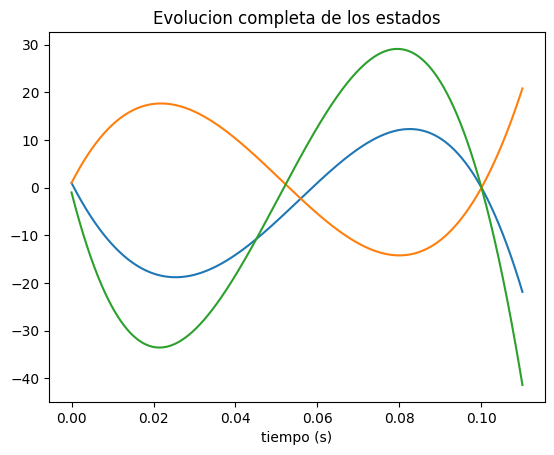

In [9]:
sol = solve_ivp(
    sistema_lineal, [0, t1 + 0.01], x0,
    args=(lambda t: U(t, A, B, eta0), A, B),
    max_step=1e-5
)

plt.figure(1)
plt.plot(sol.t, sol.y.T)
plt.xlabel('tiempo (s)')
plt.title('Evolucion completa de los estados')
plt.show()

Hacemos zoom en torno a 0.1 para comprobar que, efectivamente, en ese punto se han alcanzado los valores deseados.

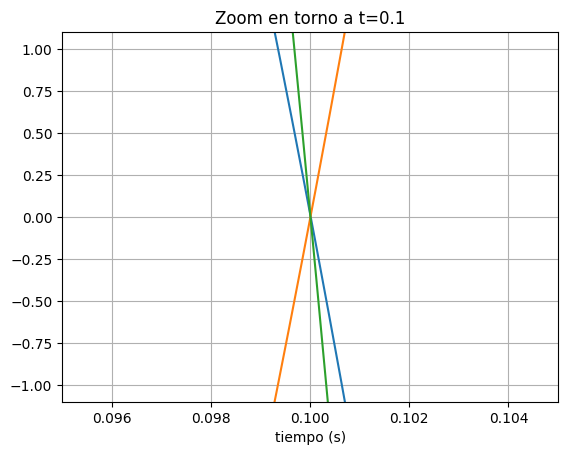

In [10]:
plt.figure(2)
plt.plot(sol.t, sol.y.T)
plt.xlim([0.095, 0.105])
plt.ylim([-1.1, 1.1])
plt.grid(True)
plt.xlabel('tiempo (s)')
plt.title('Zoom en torno a t=0.1')
plt.show()

**2. Los sistemas lineales en `control` admiten una construcción especial.** Podemos emplearla, pero hay que definir las 4 matrices $A,B,C,D$ típicas de cualquier sistema lineal.

In [11]:
C = np.eye(3)   # consideramos todos los estados como salidas del sistema
D = np.zeros((3, 1))
sys = ct.ss(A, B, C, D)
sys

StateSpace(
array([[ 1.,  2.,  3.],
       [ 2., -2.,  1.],
       [ 1.,  4., -6.]]),
array([[ 1.],
       [-1.],
       [ 2.]]),
array([[1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.]]),
array([[0.],
       [0.],
       [0.]]),
states=3, outputs=3, inputs=1)

Para poder simular la entrada debemos calcularla específicamente para un array de tiempos.

In [12]:
t1 = 0.1
t = np.arange(0, t1 + 0.001, 0.001)
Ut = np.array([U(ti, A, B, eta0) for ti in t]).flatten()
Ut.shape

(101,)

Empleamos ahora `control.forced_response`, el equivalente Python de `lsim` de MATLAB, para obtener la evolución de los estados a lo largo del tiempo. Damos una condición inicial `X0=x0` (en este caso, aunque $x_0\neq 0$, sí que hay que dársela explícitamente, a diferencia de MATLAB donde a veces se puede omitir).

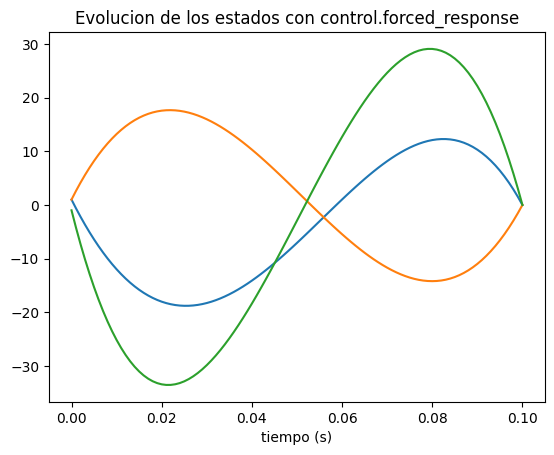

In [13]:
resp = ct.forced_response(sys, T=t, U=Ut, X0=x0)

plt.figure(3)
plt.plot(resp.time, resp.states.T)
plt.xlabel('tiempo (s)')
plt.title('Evolucion de los estados con control.forced_response')
plt.show()

## Notas finales

Es interesante observar que, mientras que el gramiano de alcanzabilidad nos proporciona un sistema para calcular una entrada $u$ que lleve el sistema a cualquier punto del espacio de estados, la matriz de controlabilidad no lo permite directamente, ni siquiera en este caso en el que la matriz de controlabilidad es invertible.